<a href="https://colab.research.google.com/github/Camilo-Rodriguez-1/Neuro_3002/blob/main/Computational_Learning_and_Memory_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import spacy
import matplotlib.pyplot as plt



In [2]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 47.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
nlp = spacy.load("en_core_web_md")

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_size=300, latent_size=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, latent_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, input_size)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [5]:
def encode_semantic(word):
    return nlp(word).vector


In [6]:
def is_anomaly(model, word, threshold):
    x = torch.FloatTensor(encode_semantic(word)).unsqueeze(0)
    with torch.no_grad():
        recon = model(x)
        error = torch.mean((x - recon) ** 2).item()
    return error > threshold, error

In [7]:
normal_inputs = [
    "login", "logout", "download",
    "upload", "scan", "open", "close"
]

X_train = torch.FloatTensor([encode_semantic(w) for w in normal_inputs])


/tmp/ipykernel_189/2615428935.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_train = torch.FloatTensor([encode_semantic(w) for w in normal_inputs])


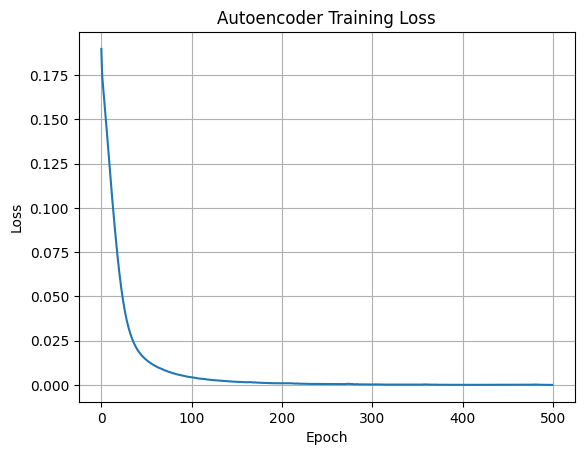

In [8]:
model = Autoencoder(input_size=300, latent_size=16)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, X_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())


plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True)
plt.show()



In [11]:
test_inputs = [
    "login",
    "logout",
    "install",
    "destroy",
    "download",
    "inject",
    "steal",
    "crown"
]

# threshold chosen empirically
threshold = np.mean(losses) * 3

for word in test_inputs:
    anomaly, err = is_anomaly(model, word, threshold)
    status = "[!] Anomaly" if anomaly else "[✓] Normal"
    print(f"{word:10} {status} (error={err:.4f})")


login      [✓] Normal (error=0.0001)
logout     [✓] Normal (error=0.0000)
install    [✓] Normal (error=0.0001)
destroy    [!] Anomaly (error=0.2175)
download   [✓] Normal (error=0.0000)
inject     [!] Anomaly (error=0.2549)
steal      [!] Anomaly (error=0.2169)
crown      [!] Anomaly (error=0.2672)
